0.23183828891362218
{0: (np.float64(-0.6955148667408666), np.float64(-0.6955148667408666)), 1: (np.float64(-0.6955148667408666), np.float64(-0.23183828891362218)), 2: (np.float64(-0.6955148667408666), np.float64(0.23183828891362218)), 3: (np.float64(-0.6955148667408666), np.float64(0.6955148667408666)), 4: (np.float64(-0.23183828891362218), np.float64(-0.6955148667408666)), 5: (np.float64(-0.23183828891362218), np.float64(-0.23183828891362218)), 6: (np.float64(-0.23183828891362218), np.float64(0.23183828891362218)), 7: (np.float64(-0.23183828891362218), np.float64(0.6955148667408666)), 8: (np.float64(0.23183828891362218), np.float64(-0.6955148667408666)), 9: (np.float64(0.23183828891362218), np.float64(-0.23183828891362218)), 10: (np.float64(0.23183828891362218), np.float64(0.23183828891362218)), 11: (np.float64(0.23183828891362218), np.float64(0.6955148667408666)), 12: (np.float64(0.6955148667408666), np.float64(-0.6955148667408666)), 13: (np.float64(0.6955148667408666), np.float64(-0

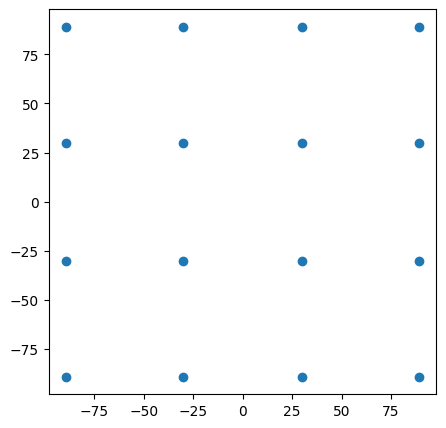

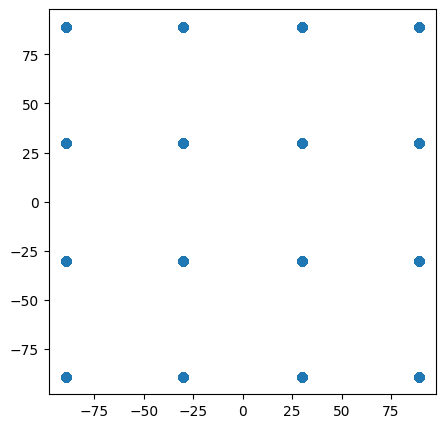

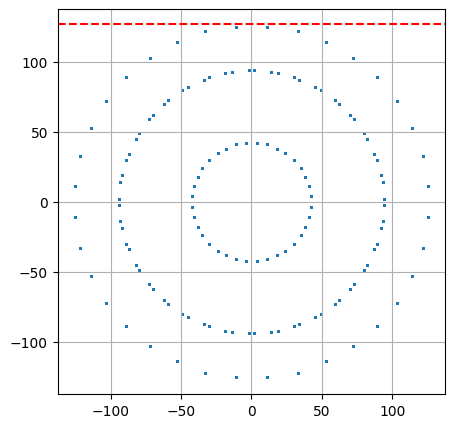

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import math as m
import math
import numpy as np
import os
import random

# script_dir = os.path.dirname(os.path.abspath(__file__))
script_dir = os.getcwd()
output_file_in  = os.path.join(script_dir, "../../RTL/carrier_recovery/input_data.txt")
output_file_out = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output.txt")
output_file_out_atan_r = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_atan_r.txt")
output_file_out_atan_a = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_atan_a.txt")
output_file_out_phase_err = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_phase_err.txt")
output_file_out_p = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_p.txt")
output_file_out_i = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_i.txt")
output_file_out_pi = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_pi.txt")
output_file_out_vco = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_vco.txt")
output_file_out_sin = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_sin.txt")
output_file_out_cos = os.path.join(script_dir, "../../RTL/carrier_recovery/expected_output_cos.txt")

# qam16_constellation = {
#     0: (-96, -96), 1: (-96, -32), 2: (-96, 32), 3: (-96, 96),
#     4: (-32, -96), 5: (-32, -32), 6: (-32, 32), 7: (-32, 96),
#     8: (32, -96), 9: (32, -32), 10: (32, 32), 11: (32, 96),
#     12: (96, -96), 13: (96, -32), 14: (96, 32), 15: (96, 96)
# }

qam16_constellation = {
    0: (-3, -3), 1: (-3, -1), 2: (-3, 1), 3: (-3, 3),
    4: (-1, -3), 5: (-1, -1), 6: (-1, 1), 7: (-1, 3),
    8: (1, -3), 9: (1, -1), 10: (1, 1), 11: (1, 3),
    12: (3, -3), 13: (3, -1), 14: (3, 1), 15: (3, 3)
}

k = np.real( complex(1,0) * np.exp(1j*np.deg2rad(45)) ) / 3.05

print(k)

qam16_constellation = {key: (k * I, k * Q) for key, (I, Q) in qam16_constellation.items()}
print(qam16_constellation)
qam16_constellation = {key: (round(I*2**7), round(Q*2**7)) for key, (I, Q) in qam16_constellation.items()}

symbols=np.array([complex(i,q) for i,q in qam16_constellation.values()])
plt.figure(figsize=(5,5))
plt.scatter(np.real(symbols), np.imag(symbols))

n_samples=10000

indices = np.random.randint(0, len(symbols), n_samples)
tx_symbols = symbols[indices]
# tx_symbols = symbols[1]
plt.figure(figsize=(5,5))
plt.scatter(np.real(tx_symbols), np.imag(tx_symbols))

freq_offset = 20*np.pi/180

n = np.arange(n_samples)
rx_symbols = np.round(tx_symbols * np.exp(1j *  freq_offset * n))

plt.figure(figsize=(5,5))
plt.grid()
plt.scatter(np.real(rx_symbols), np.imag(rx_symbols), s=1)
plt.axhline(y=127, color='r', linestyle='--', label="y=127")

print(rx_symbols)

kp: 0.5 ki: 0.046875
Damping Ratio (ζ): 1.1547005383792517
Overdamped (Slow Response): ζ>1


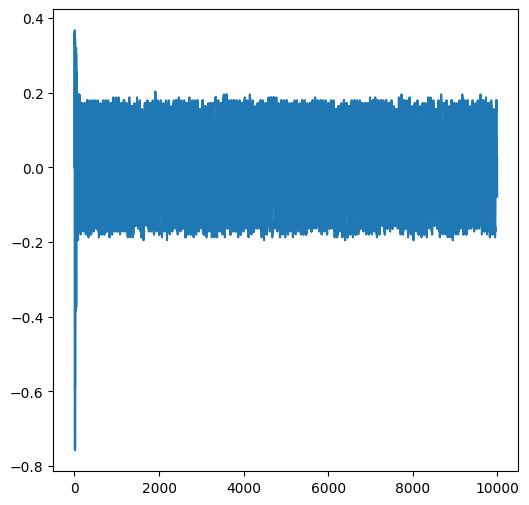

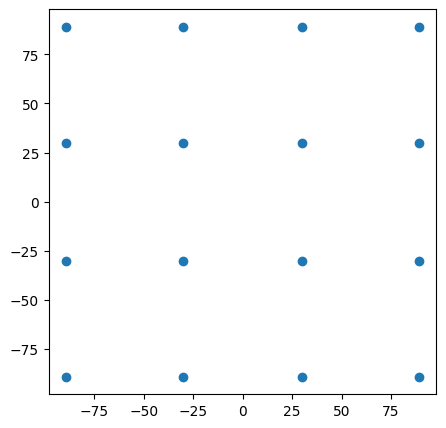

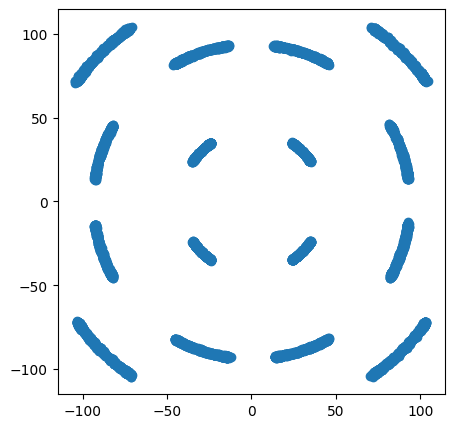

In [66]:
recovered_symbols = np.zeros(n_samples, dtype=complex)

Kp = 0.5
Ki = round(0.05*2**7)/2**7
print(f"kp: {Kp} ki: {Ki}")

zeta = Kp / (2 * np.sqrt(Ki))
delay=15

print(f"Damping Ratio (ζ): {zeta}")
if(zeta < 1):
        print("Underdamped (Oscillatory Response): ζ<1")
elif (zeta == 1):
        print("Critically Damped (Fastest No-Overshoot Response): ζ=1")
else:
        print("Overdamped (Slow Response): ζ>1")

phase_nco = 0  
phase_nco_next = np.zeros(n_samples+1)  
phase_error_next = np.zeros(n_samples+delay)  
freq_nco = 0   
integrator = 0 
phase_errors = np.zeros(n_samples)
freq_nco_i = np.zeros(n_samples)
phase_nco_i = np.zeros(n_samples)
symbol_a = complex(0)

def slicer(i_received_symbol):
        if (i_received_symbol < -64): 
                return -96
        elif (i_received_symbol < 0): 
                return -32
        elif (i_received_symbol < 64):  
                return 32 
        else:  
                return 96
               
def f_integer(bits, number):
        return int(number) & ((1 << bits) - 1)

def rroun(num):
        return round(num*2**7)/2**7

NBF_RES = 7

with open(output_file_in, "w") as f_in, open(output_file_out, "w") as f_out, open(output_file_out_atan_r, "w") as f_out_atan_r ,open(output_file_out_atan_a, "w") as f_out_atan_a , open(output_file_out_phase_err, "w") as f_out_phase_err, open(output_file_out_p, "w") as f_out_p, open(output_file_out_i, "w") as f_out_i, open(output_file_out_pi, "w") as f_out_pi, open(output_file_out_vco, "w") as f_out_vco, open(output_file_out_sin, "w") as f_out_sin, open(output_file_out_cos, "w") as f_out_cos:

        for i in range(n_samples): 
                a = np.real(rx_symbols[i])
                b = np.imag(rx_symbols[i])


                x = phase_nco_next[i]

                
                cosx= rroun(np.cos(x))
                sinx= rroun(np.sin(x))

                
                real_corrected = rroun(a * cosx + b * sinx)
                imag_corrected = rroun(b * cosx - a * sinx)
                
                corrected_symbol = real_corrected + 1j * imag_corrected
                # corrected_symbol = rx_symbols[i] * np.exp(-1j * phase_nco)

                phase_r = rroun(m.atan2(np.imag(corrected_symbol), np.real(corrected_symbol)))
                
                
                symbol_a = slicer(np.real(corrected_symbol)) + 1j * slicer(np.imag(corrected_symbol))
                phase_a = rroun((m.atan2(np.imag(symbol_a),np.real(symbol_a))))

                
                # closest_symbol = symbols[np.argmin(abs(symbols - corrected_symbol))]
                # phase_error = np.angle(corrected_symbol * np.conj(closest_symbol))
                phase_error = rroun(phase_r - phase_a)
                phase_error_next[i+delay] = phase_error
                
                phase_errors[i] = phase_error
                
                integrator += rroun(Ki * phase_error_next[i])  

                if integrator <= -2*np.pi:
                        integrator = integrator+2*np.pi
                elif integrator >= 2*np.pi:
                        integrator = integrator-2*np.pi
                
                f_out_i.write(f"{round(integrator*2**NBF_RES)}\n")

                freq_nco = rroun(rroun(Kp * phase_error) + integrator)          
                phase_nco += freq_nco  


                freq_nco_i[i] = freq_nco

                phase_nco += freq_nco  
                
                phase_nco_next[i+1] = phase_nco

                if phase_nco_next[i+1] <= -2*np.pi:
                        phase_nco_next[i+1] = phase_nco_next[i+1]+2*np.pi
                elif phase_nco_next[i+1] >= 2*np.pi:
                        phase_nco_next[i+1] = phase_nco_next[i+1]-2*np.pi
                
                phase_nco_i[i] = phase_nco
                
                recovered_symbols[i] = corrected_symbol

                f_in.write(           f"{int(b)} {int(a)}\n")
                f_out_sin.write(      f"{round(np.sin(x)*2**NBF_RES)}\n")
                f_out_cos.write(      f"{round(np.cos(x)*2**NBF_RES)}\n")
                f_out.write(          f"{int(real_corrected)} {int(imag_corrected)}\n")
                f_out_atan_r.write(   f"{round(phase_r*2**NBF_RES)}\n")
                f_out_atan_a.write(   f"{round(phase_a*2**NBF_RES)}\n")
                f_out_phase_err.write(f"{round(phase_error*2**NBF_RES)}\n")
                f_out_p.write(        f"{round(Kp * phase_error*2**NBF_RES)}\n")
                f_out_pi.write(       f"{round(freq_nco*2**NBF_RES)}\n")
                f_out_vco.write(      f"{round(phase_nco_next[i]*2**NBF_RES)}\n")


# plt.figure(figsize=(12,6))
# plt.plot( range(n_samples), freq_nco_i)
# plt.xlim(0,2000)

# plt.figure(figsize=(12,6))
# plt.plot( range(n_samples), phase_nco_i)
# plt.xlim(1750,2000)

plt.figure(figsize=(6,6))
plt.plot( range(n_samples), phase_errors   )
# plt.xlim(0,1000)

plt.figure(figsize=(5,5))
plt.scatter(np.real(symbols), np.imag(symbols))

plt.figure(figsize=(5,5))
plt.scatter(np.real(recovered_symbols[2500:len(recovered_symbols)]),np.imag(recovered_symbols[2500:len(recovered_symbols)]))
